# Full Spearman decision-alignment analysis

Metric 4 (judge-free anchor): does each config's `review.json` rating rank the 25 papers
the same way human mean scores do? Read from `eval/results/full/spearman.json`.

Per config we have overall Spearman ρ with p-value and a percentile bootstrap 95% CI
(2000 resamples), plus a `normal` / `controversial` stratum split. ρ is rank correlation
in `[-1, 1]`; higher means the config's accept/reject signal tracks human consensus.

In [6]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_SET = "full"

# Walk up until we find eval/ so the notebook runs regardless of CWD.
ROOT = Path.cwd()
while not (ROOT / "eval").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

RESULTS_DIR = ROOT / "eval" / "results" / RUN_SET
BATCHES = ROOT / "eval" / "batches.json"
FIG_DIR = ROOT / "eval" / "analysis" / "figures" / RUN_SET
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- palette (seaborn deep quad) ---
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
MODEL_COLORS = {"A": PALETTE[0], "B": PALETTE[1], "C": PALETTE[2]}
MODEL_NAMES = {"A": "qwen3-32b", "B": "mistral-small-3.2", "C": "llama-3.3-70b"}
ROLE_COLORS = dict(zip(
    ("leader", "clarity", "experiments", "impact"), PALETTE
))
ROLES = ("leader", "clarity", "experiments", "impact")
C_HET, C_REF = PALETTE[0], PALETTE[1]  # blue het, orange ref
C_ANNOT, C_MUTED, C_REF_LINE, C_EDGE, C_ERR = (
    "#333333", "#555555", "#666666", "#FFFFFF", "#333333",
)
# --- layout constants (fixed legend gap from figure bottom) ---
LEGEND_Y = 0.035          # figure coords — same on every plot
MARGIN_NO_LEGEND = 0.12
MARGIN_LEGEND = 0.22      # barh / scatter with legend, no rotated x
MARGIN_XROT30 = 0.28
MARGIN_XROT45 = 0.32
MARGIN_HEATMAP = 0.28
SAVE_PAD = 0.12


def legend_bottom(*, xrot=0, titled=False):
    if xrot >= 40:
        b = MARGIN_XROT45
    elif xrot >= 20:
        b = MARGIN_XROT30
    else:
        b = MARGIN_LEGEND
    if titled:
        b += 0.04
    return b


def legend_below(
    fig, ax=None, *, handles=None, labels=None, ncol=2, title=None, xrot=0,
):
    """Figure-level legend at fixed LEGEND_Y. Returns bottom margin for save_fig."""
    if handles is None:
        if ax is None:
            raise ValueError("legend_below needs ax or explicit handles")
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
        handles, labels = ax.get_legend_handles_labels()
    kw = dict(
        loc="lower center", bbox_to_anchor=(0.5, LEGEND_Y), ncol=ncol,
        fontsize=8, framealpha=0.95, edgecolor="#CCCCCC", frameon=True,
    )
    if title:
        kw["title"] = title
    fig.legend(handles, labels, **kw)
    return legend_bottom(xrot=xrot, titled=title is not None)


def annotate_configs(ax, x, y, configs, *, fontsize=7, offsets_by_name=None):
    """Config slug near each scatter point."""
    defaults = [
        (7, 5), (7, -7), (-7, 5), (-7, -7),
        (10, 0), (-10, 0), (0, 9), (0, -9),
    ]
    for i, (xi, yi, name) in enumerate(zip(x, y, configs)):
        dx, dy = (offsets_by_name or {}).get(name, defaults[i % len(defaults)])
        ax.annotate(
            name, (xi, yi), textcoords="offset points", xytext=(dx, dy),
            fontsize=fontsize, color=C_ANNOT,
            ha="left" if dx >= 0 else "right",
            va="bottom" if dy >= 0 else "top",
        )


def pad_axes_for_labels(ax, *, xfrac=0.06, yfrac=0.08):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ax.set_xlim(x0 - (x1 - x0) * xfrac, x1 + (x1 - x0) * xfrac)
    ax.set_ylim(y0 - (y1 - y0) * yfrac, y1 + (y1 - y0) * yfrac)


def save_fig(fig, path, *, bottom=MARGIN_NO_LEGEND, top=0.90, left=None, right=None):
    kw = dict(bottom=bottom, top=top)
    if left is not None:
        kw["left"] = left
    if right is not None:
        kw["right"] = right
    fig.subplots_adjust(**kw)
    fig.savefig(path, bbox_inches="tight", pad_inches=SAVE_PAD)


LEGEND_KW = dict(
    loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2,
    fontsize=8, framealpha=0.95, edgecolor="#CCCCCC", frameon=True,
)

FIG_RANK, FIG_COMPACT = (8.5, 4.5), (6, 3.6)
FIG_SCATTER, FIG_PANEL, FIG_WIDE = (7, 5), (9.5, 3.8), (12, 4.0)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 8,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.alpha": 0.25, "grid.color": "#E0E0E0", "grid.linestyle": "-",
    "lines.linewidth": 1.5, "patch.linewidth": 0.5,
})


def fig_title(desc: str, *, n_papers: int | None = None, extra: str = "") -> str:
    """Notebook title — keep light; LaTeX captions carry detail."""
    parts = []
    if RUN_SET == "pilot":
        parts.append("pilot")
    if n_papers is not None and (RUN_SET == "pilot" or n_papers != 25):
        parts.append(f"n={n_papers} papers")
    if extra:
        parts.append(extra)
    return f"{desc} ({', '.join(parts)})" if parts else desc


batch = json.loads(BATCHES.read_text())[RUN_SET]
pool = batch["pool"]
slug_to_letter = {v: k for k, v in pool.items()}


def letter(value: str) -> str:
    if value in pool:
        return value
    return slug_to_letter.get(value, value)


def tuple_letters(cfg: str) -> tuple[str, ...]:
    m = batch["configs"][cfg]
    return tuple(letter(m[r]) for r in ROLES)


def is_homogeneous(cfg: str) -> bool:
    return len(set(tuple_letters(cfg))) == 1


RESULTS = RESULTS_DIR / "spearman.json"
sp = json.loads(RESULTS.read_text())

per_config = sp["per_config"]
order = [c for c in batch["configs"] if c in per_config]

rows = []
for c in order:
    o = per_config[c]["overall"]
    rows.append({
        "config": c, "tuple": ",".join(tuple_letters(c)), "homogeneous": is_homogeneous(c),
        "rho": o["rho"], "p_value": o["p_value"],
        "ci_low": o["ci_low"], "ci_high": o["ci_high"], "n": o["n"],
    })
df = pd.DataFrame(rows)

print(f"run-set    : {RUN_SET}")
print(f"bootstrap_n: {sp['bootstrap_n']}")
print(f"configs    : {len(df)}   n papers: {int(df['n'].iloc[0])}")
df.round(4)

run-set    : full
bootstrap_n: 2000
configs    : 7   n papers: 25


,config,tuple,homogeneous,rho,p_value,ci_low,ci_high,n
0,All-A,"A,A,A,A",True,0.4734,0.0168,0.1254,0.7080,25
1,All-B,"B,B,B,B",True,0.3673,0.0709,-0.0581,0.7075,25
2,All-C,"C,C,C,C",True,0.2647,0.2011,-0.1812,0.6405,25
3,specialist,"A,B,A,C",False,0.6001,0.0015,0.3096,0.7977,25
4,swap_experiments,"B,B,A,B",False,0.3674,0.0708,-0.0561,0.6938,25
5,rot_2,"B,C,A,B",False,0.3325,0.1044,-0.1225,0.6706,25
6,swap_leader,"A,B,B,B",False,0.5972,0.0016,0.2592,0.7869,25


## Score distributions — humans vs models

Before reading ρ, check calibration: human mean rating is one value per paper (fractional);
model ratings are the integer `RATING:` parsed from each config's `review.json`, pooled
across all configs. Heavy mass at 8–9 with little spread is **rating compression** — it
limits how much rank-correlation (Spearman) can say.

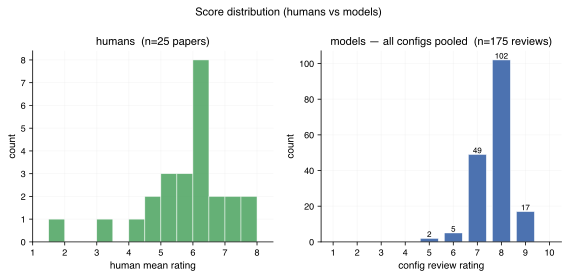

,human mean (per paper),model score (pooled)
count,25.00,175.00
mean,5.64,7.73
std,1.36,0.72
min,1.50,5.00
25%,5.00,7.00
50%,6.00,8.00
75%,6.25,8.00
max,7.50,9.00


Model score counts: {5.0: np.int64(2), 6.0: np.int64(5), 7.0: np.int64(49), 8.0: np.int64(102), 9.0: np.int64(17)}
  fraction rated 8: 58.3%
  fraction rated ≥8: 68.0%


In [7]:
score_rows = []
for cfg in order:
    for p in per_config[cfg]["pairs"]:
        score_rows.append({
            "config": cfg,
            "paper_id": p["paper_id"],
            "human_mean": p["human_mean"],
            "config_score": p["config_score"],
        })
scores = pd.DataFrame(score_rows)
human = scores.drop_duplicates("paper_id")[["paper_id", "human_mean"]]
model_scores = scores["config_score"]

fig, axes = plt.subplots(1, 2, figsize=FIG_PANEL)

ax = axes[0]
ax.hist(human["human_mean"], bins=np.arange(1.0, 8.25, 0.5),
        color=MODEL_COLORS["C"], edgecolor=C_EDGE, alpha=0.9)
ax.set_xlabel("human mean rating")
ax.set_ylabel("count")
ax.set_title(f"humans  (n={len(human)} papers)")
ax.set_xlim(1, 8.5)

ax = axes[1]
counts = model_scores.value_counts().sort_index()
ax.bar(counts.index, counts.values, color=C_HET, edgecolor=C_EDGE, width=0.75)
for x, v in counts.items():
    ax.text(x, v, str(v), ha="center", va="bottom", fontsize=8)
ax.set_xlabel("config review rating")
ax.set_ylabel("count")
ax.set_title(f"models — all configs pooled  (n={len(model_scores)} reviews)")
ax.set_xticks(range(1, 11))
ax.set_xlim(0.5, 10.5)

fig.suptitle(fig_title("Score distribution (humans vs models)"), y=0.98, fontsize=11)
save_fig(fig, FIG_DIR / "spearman_score_distributions.png", bottom=MARGIN_NO_LEGEND, top=0.82)
plt.show()

summary = pd.DataFrame({
    "human mean (per paper)": human["human_mean"].describe(),
    "model score (pooled)": model_scores.describe(),
}).round(2)
display(summary)
print("Model score counts:", dict(model_scores.value_counts().sort_index()))
print(f"  fraction rated 8: {(model_scores == 8).mean():.1%}")
print(f"  fraction rated ≥8: {(model_scores >= 8).mean():.1%}")


## 1. Overall ρ with bootstrap CI

Each **bar** is one config's Spearman ρ: how similarly that config *ranks* the 25 papers
compared with human mean scores (rank agreement, not absolute rating match; ρ = 1 perfect,
0 = none, −1 = reversed). **Error bars** are the 95% bootstrap CI from resampling papers;
if the CI crosses the vertical zero line, alignment is not distinguishable from chance.
Text labels sit just past the upper CI bound; `*` = analytic p < 0.05.

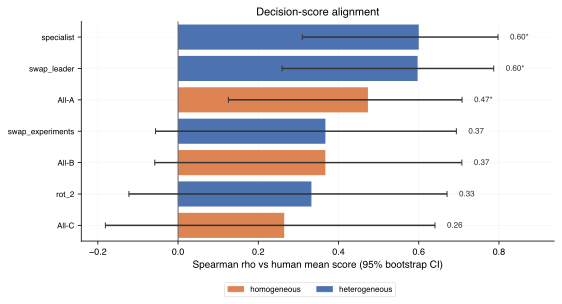

* = p < 0.05 (analytic)


In [8]:
d = df.sort_values("rho").reset_index(drop=True)
colors = [C_REF if h else C_HET for h in d["homogeneous"]]
y = np.arange(len(d))
xerr_lo = (d["rho"] - d["ci_low"]).clip(lower=0)
xerr_hi = (d["ci_high"] - d["rho"]).clip(lower=0)

fig, ax = plt.subplots(figsize=FIG_RANK)
ax.barh(y, d["rho"], color=colors,
        xerr=[xerr_lo, xerr_hi], error_kw={"ecolor": C_ERR, "capsize": 3})
ax.axvline(0, color=C_REF_LINE, lw=1, zorder=1)
ax.set_yticks(y)
ax.set_yticklabels(d["config"], fontsize=8)

for yy, row in enumerate(d.itertuples()):
    rho, p, hi = row.rho, row.p_value, row.ci_high
    if rho is None or hi is None:
        continue
    star = "*" if (p is not None and p < 0.05) else ""
    ax.text(hi + 0.03, yy, f"{rho:.2f}{star}", va="center", ha="left", fontsize=8, color=C_ANNOT)

x_left = min(d["ci_low"].min(), 0) - 0.06
x_right = d["ci_high"].max() + 0.14
ax.set_xlim(x_left, x_right)
ax.set_ylim(-0.5, len(d) - 0.5)
ax.set_xlabel("Spearman rho vs human mean score (95% bootstrap CI)")
ax.set_title(fig_title("Decision-score alignment"))
bottom = legend_below(fig, handles=[
    plt.Rectangle((0, 0), 1, 1, color=C_REF),
    plt.Rectangle((0, 0), 1, 1, color=C_HET),
], labels=["homogeneous", "heterogeneous"], ncol=2)
save_fig(fig, FIG_DIR / "spearman_overall.png", bottom=bottom)
plt.show()
print("* = p < 0.05 (analytic)")


## 2. By stratum — normal vs. controversial

Alignment often holds on clear-cut (`normal`) papers but collapses on `controversial`
ones where humans themselves disagree. Side-by-side ρ per stratum; stratum sample
sizes are in the legend / table columns (same for every config). Bars are omitted
where a stratum has too few papers / no rank variance (ρ = null).

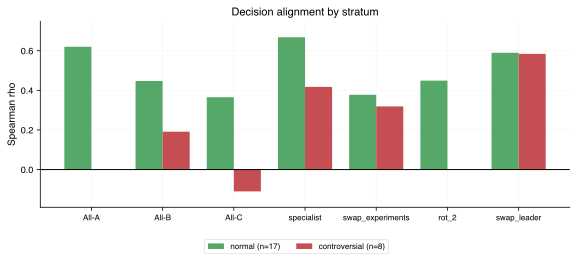

,normal (n=17),controversial (n=8)
All-A,0.620,NaN
All-B,0.447,0.191
All-C,0.365,-0.110
specialist,0.668,0.417
swap_experiments,0.378,0.319
rot_2,0.449,0.000
swap_leader,0.590,0.584


In [9]:
strata = ["normal", "controversial"]
n_by_stratum = {s: per_config[order[0]]["by_stratum"][s]["n"] for s in strata}
sd = {s: [] for s in strata}
for c in order:
    for s in strata:
        sd[s].append(per_config[c]["by_stratum"].get(s, {}).get("rho"))

x = np.arange(len(order)); w = 0.38
fig, ax = plt.subplots(figsize=FIG_PANEL)
spal = {"normal": PALETTE[2], "controversial": PALETTE[3]}
for i, s in enumerate(strata):
    vals = [np.nan if v is None else v for v in sd[s]]
    ax.bar(x + (i - 0.5) * w, vals, w, label=f"{s} (n={n_by_stratum[s]})", color=spal[s])

ax.axhline(0, color="black", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(order, fontsize=8)
vals_flat = [v for s in strata for v in sd[s] if v is not None]
y_lo = min(min(vals_flat, default=0), 0) - 0.08
y_hi = max(vals_flat, default=1) + 0.08
ax.set_ylim(y_lo, y_hi)
ax.set_ylabel("Spearman rho")
ax.set_title(fig_title("Decision alignment by stratum"))
bottom = legend_below(fig, ax, ncol=2)
save_fig(fig, FIG_DIR / "spearman_by_stratum.png", bottom=bottom)
plt.show()

display(pd.DataFrame({
    f"normal (n={n_by_stratum['normal']})": sd["normal"],
    f"controversial (n={n_by_stratum['controversial']})": sd["controversial"],
}, index=order).round(3))


## 3. Score scatter for a chosen config

The raw join behind ρ: each point is one paper (`config` rating vs human mean), coloured
by stratum. Jitter separates tied integer config scores. The dashed diagonal is **y = x**
(numeric agreement); Spearman ρ measures **rank** agreement, so points can rank well
while sitting off the diagonal. Defaults to the top-ρ config; change `FOCUS` to inspect others.

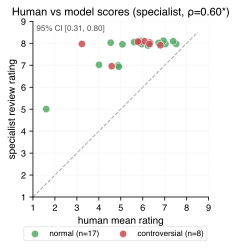

In [10]:
FOCUS = df.sort_values("rho", ascending=False).iloc[0]["config"]
pairs = per_config[FOCUS]["pairs"]
pdf = pd.DataFrame(pairs)
n_by_stratum = pdf["stratum"].value_counts().to_dict()

rng = np.random.default_rng(0)
jx = rng.uniform(-0.12, 0.12, len(pdf))
jy = rng.uniform(-0.12, 0.12, len(pdf))
spal = {"normal": PALETTE[2], "controversial": PALETTE[3]}

lo = min(pdf["human_mean"].min(), pdf["config_score"].min()) - 0.5
hi = max(pdf["human_mean"].max(), pdf["config_score"].max()) + 0.5
tick_lo, tick_hi = int(np.floor(lo)), int(np.ceil(hi))

fig, ax = plt.subplots(figsize=FIG_COMPACT)
ax.plot([lo, hi], [lo, hi], ls="--", color="#aaaaaa", lw=1, zorder=0)
for s in ["normal", "controversial"]:
    m = pdf["stratum"] == s
    ax.scatter(
        pdf.loc[m, "human_mean"] + jx[m.values],
        pdf.loc[m, "config_score"] + jy[m.values],
        c=spal[s], label=f"{s} (n={int(n_by_stratum.get(s, 0))})",
        alpha=0.85, edgecolors="white", linewidths=0.6, s=55, zorder=2,
    )

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")
ax.set_xticks(range(tick_lo, tick_hi + 1))
ax.set_yticks(range(tick_lo, tick_hi + 1))
ax.set_xlabel("human mean rating")
ax.set_ylabel(f"{FOCUS} review rating")
o = per_config[FOCUS]["overall"]
pstar = "*" if o.get("p_value") is not None and o["p_value"] < 0.05 else ""
ax.set_title(fig_title("Human vs model scores", extra=f"{FOCUS}, ρ={o['rho']:.2f}{pstar}"))
ax.text(0.02, 0.98, f"95% CI [{o['ci_low']:.2f}, {o['ci_high']:.2f}]",
        transform=ax.transAxes, va="top", ha="left", fontsize=8, color=C_MUTED)
bottom = legend_below(fig, ax, ncol=2)
save_fig(fig, FIG_DIR / f"spearman_scatter_{FOCUS}.png", bottom=bottom)
plt.show()


## 4. Takeaways

_Fill once reviewed:_
1. **Which configs align best** with human decisions, and are any CIs tight enough / clear
   of 0 to claim real alignment on n=25?
2. **Heterogeneous vs. homogeneous** — does mixing models improve decision alignment, or is
   this metric flat across configs (alignment is a model-capability property, not a seating one)?
3. **Stratum effect** — does alignment survive on `controversial` papers, or only hold where
   humans agree?